In [1]:
import superstats as sup
import bayesflow as bf
import numpy as np

Defaulting to JAX.
To override, set the KERAS_BACKEND environment variable before importing bayesflow.
See: https://keras.io/getting_started/#configuring-your-backend
INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
INFO:bayesflow:Using backend 'jax'


## Constants

In [2]:
NUM_STEPS = 100
NUM_SAMPLES = 500
NUM_EPOCHS = 100
BATCH_SIZE = 32

## Prior

In [3]:
joint_prior = sup.prior.JointPrior(
    v = sup.transition.RandomWalk(
            bounds=(0.0, 6.0),
            sigma=sup.prior.Prior(dist="halfnormal", scale=0.1),
            delta=0,
            initial_prior=sup.prior.Prior(dist="normal", loc=-1.5, scale=0.5)
        ),
    a = sup.transition.RandomWalk(
            bounds=(0.0, 4.0),
            sigma=sup.prior.Prior(dist="halfnormal", scale=0.1),
            delta=0,
            initial_prior=sup.prior.Prior(dist="normal", loc=0.0, scale=0.5)
        ),
    tau = sup.transition.RandomWalk(
            bounds=(0.0, 2.0),
            sigma=sup.prior.Prior(dist="halfnormal", scale=0.1),
            delta=0,
            initial_prior=sup.prior.Prior(dist="normal", loc=-1.5, scale=0.5)
        ),
    bias = 0.5
)

generative_model = sup.simulation.GenerativeModel(
    prior=joint_prior,
    model=sup.simulation.sample_ddm,
    missing="random"
)

/home/radevs/anaconda3/envs/bfjax/lib/python3.12/site-packages/numba/np/ufunc/parallel.py:373: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)


## Workflow

In [ ]:
workflow = sup.workflow.Workflow(
    simulator=generative_model,
    summary_network=sup.networks.RecurrentNet(time_embed_dim=4)
)

## Training

In [5]:
training_data = generative_model.sample(10_000, num_steps=NUM_STEPS, tile_to_steps=True)
val_data = generative_model.sample(100, num_steps=NUM_STEPS, tile_to_steps=True)

In [6]:
history = workflow.fit_offline(
    data=training_data,
    validation_data=val_data,
    epochs=50,
    batch_size=BATCH_SIZE
)

INFO:bayesflow:Fitting on dataset instance of OfflineDataset.
INFO:bayesflow:Building on a test batch.


Epoch 1/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 44ms/step - loss: 7.3051 - val_loss: 5.9418
Epoch 2/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 6.0883 - val_loss: 5.7202
Epoch 3/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - loss: 5.9459 - val_loss: 5.5966
Epoch 4/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - loss: 5.7531 - val_loss: 5.3630
Epoch 5/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - loss: 5.5407 - val_loss: 5.2205
Epoch 6/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - loss: 5.4495 - val_loss: 5.0944
Epoch 7/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - loss: 5.3805 - val_loss: 5.1055
Epoch 8/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - loss: 5.2805 - val_loss: 4.9621
Epoch 9/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - loss: 5.0289 - val_loss: 4.6901
Epoch 10/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - loss: 4.8621 - val_loss: 4.7068
Epoch 11/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - loss: 4.7579 - val_loss: 4.4609
Epoch 12/50
313/313 ━━━━━━━━━━━━━━━━━━━━

INFO:bayesflow:Training completed in 5.61 minutes.


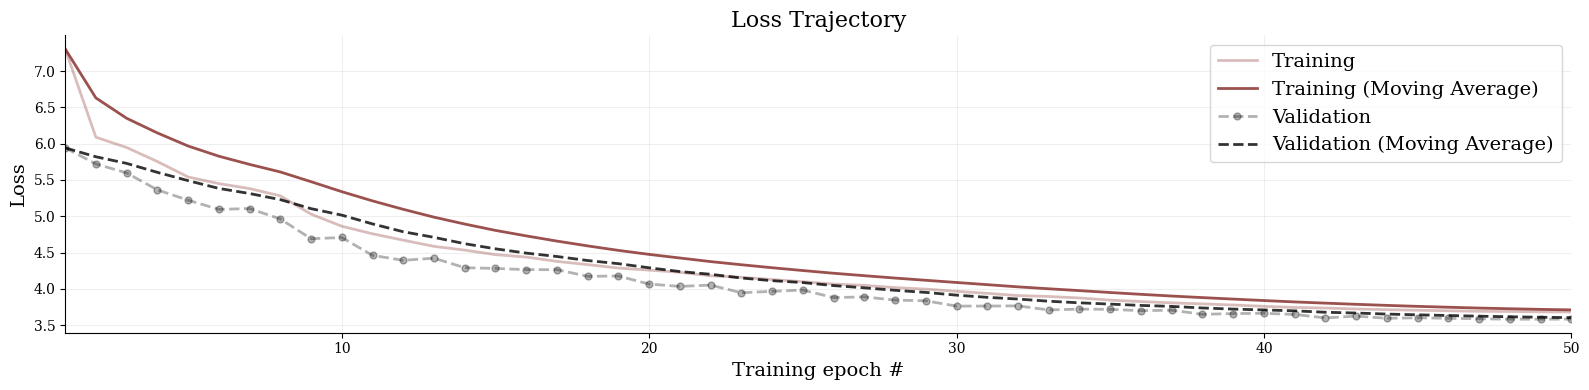

In [14]:
fig = workflow.plot_history(workflow.history)

## Verification

In [15]:
test_data = workflow.simulator.sample(
    batch_size=100,
    num_steps=NUM_STEPS,
    tile_to_steps=False
)

In [18]:
samples = workflow.sample(
    data=test_data,
    num_samples=300,
    batch_size=8
)

Summarizing:   0%|          | 0/13 [00:00<?, ?batch/s]

Sampling:   0%|          | 0/13 [00:00<?, ?batch/s]

### Time-varying Parameters

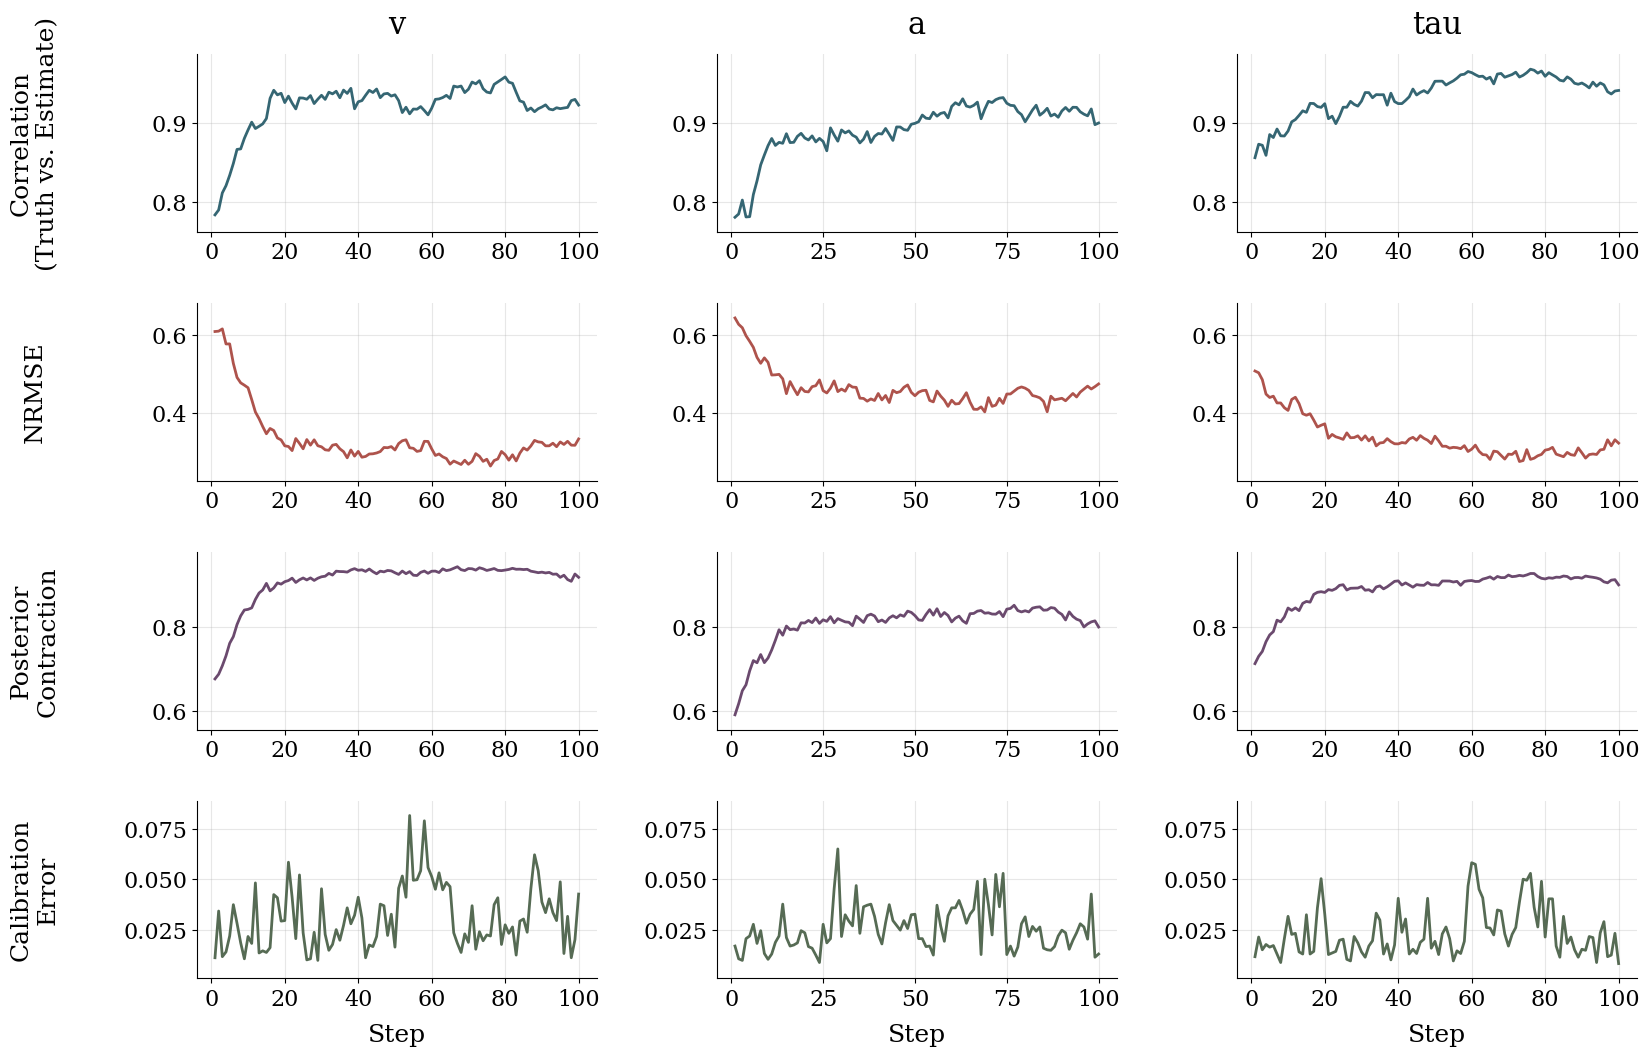

In [19]:
fig = workflow.verify_time_varying(test_data, samples)

In [20]:
time_step = 99
local_keys = workflow.simulator.local_keys
true = np.stack([test_data[k][:, time_step, 0] for k in local_keys], axis=-1)
estimates = np.stack([samples[k][:, :, time_step, 0] for k in local_keys], axis=-1)

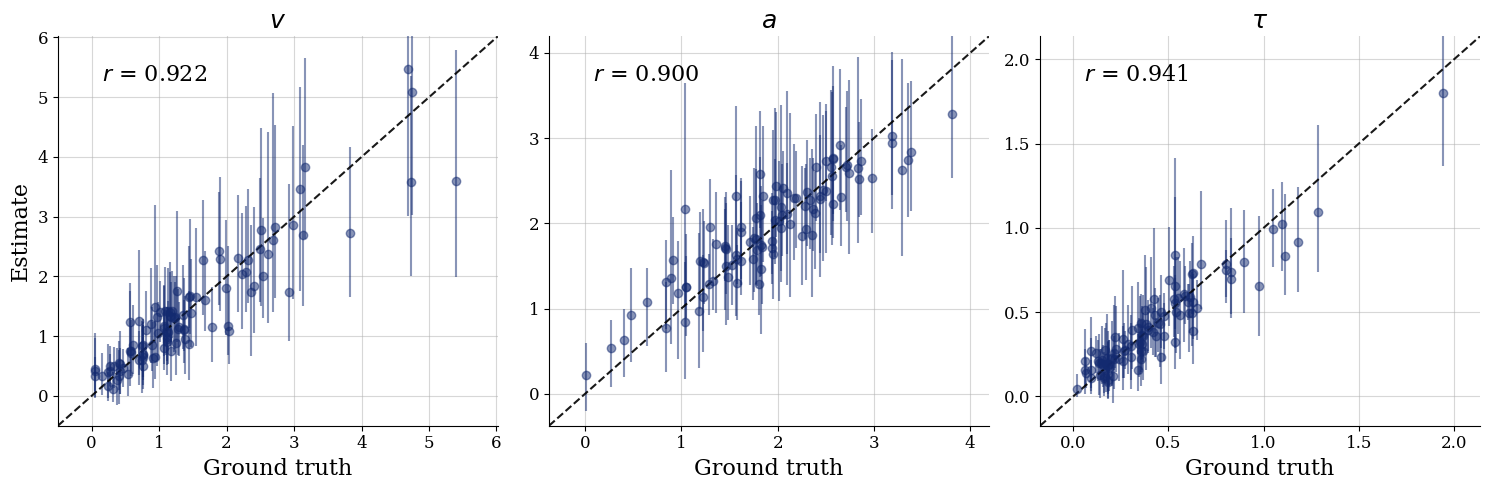

In [21]:
fig = bf.diagnostics.plots.recovery(
    estimates,
    true,
    variable_names = [r"$v$", r"$a$", r"$\tau$"],
)

### Time-invariant Parameters

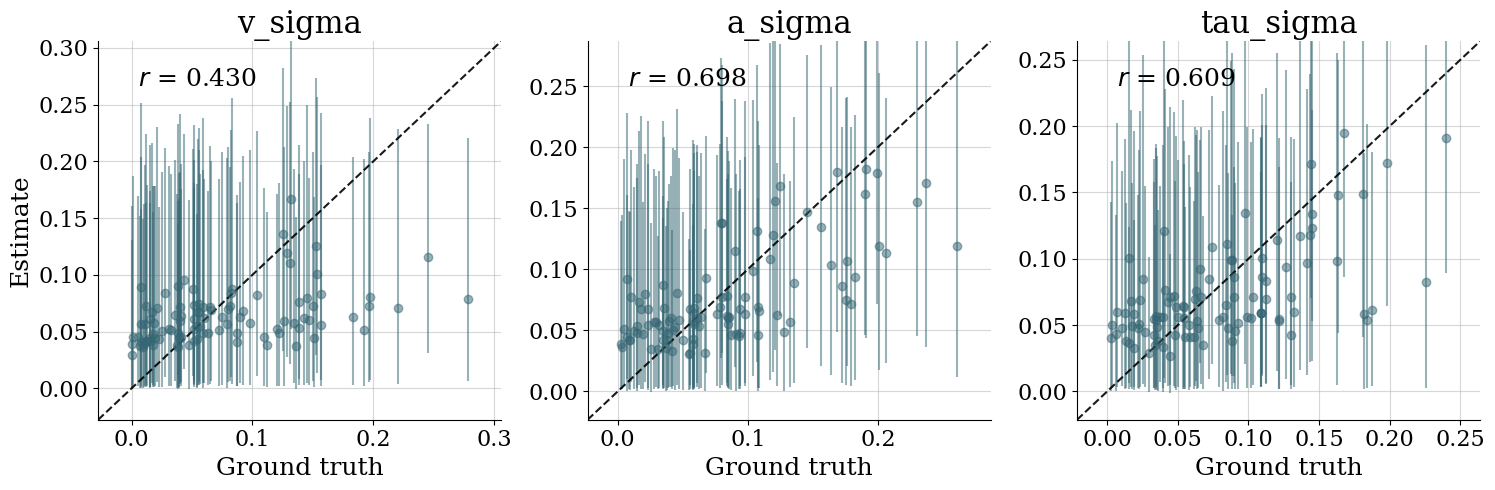

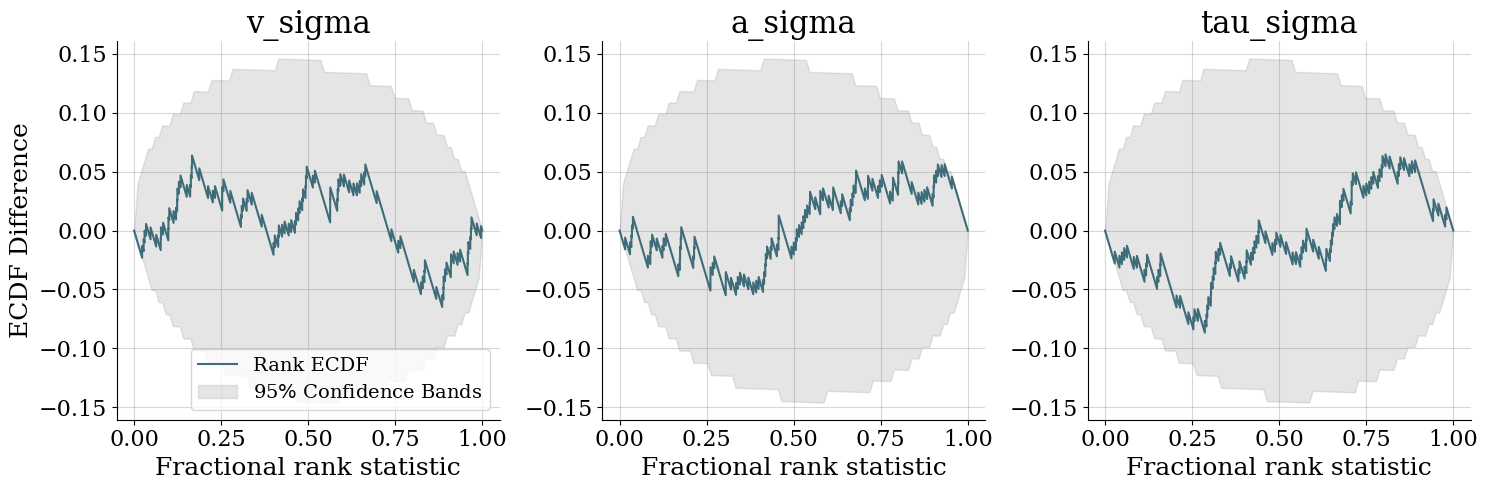

In [13]:
fig_recovery, fig_calibration = workflow.verify_time_invariant(
    test_data,
    samples
)